CTU-UHB Intrapartum Cardiotocography Database (Feb. 18, 2014)

This collection of 552 CTGs from the Czech Technical University (CTU) in Prague and the University Hospital in Brno (UHB) was carefully selected from 9164 recordings recently collected at UHB. Each recording is up to 90 minutes long, and includes a fetal heart rate time series, a uterine contraction signal, and maternal, delivery, and fetal clinical details.



In [5]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np

record_id = "1001"
data_dir='/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/data/ctu_chb_data'
record = wfdb.rdrecord(f"{data_dir}/{record_id}")
# record.__dict__

def visualize_ctg_data(record, raw=True, sample=0):
    """
    Visualize CTG data from .dat and .hea files for a given record ID.

    Parameters:
    - record_id (str): The ID of the record to visualize.
    - data_dir (str): Directory where the data files are stored.

    Returns:
    None (displays a plot)
    """
    # try:
        # Read the signal data

    # Extract signal data and time
    time = np.arange(10)
    fhr = np.arange(10)
    uc = np.arange(10)

    if raw:
        # Extract signal data and time
        time = np.arange(len(record.p_signal)) / record.fs / 60  # Convert to minutes
        fhr = record.p_signal[:, 0]  # Fetal Heart Rate
        uc = record.p_signal[:, 1]   # Uterine Contractions
    else:
        # Extract signal data and time
        time = np.arange(len(record.p_signal)) / record.fs / 60  # Convert to minutes
        fhr = record.p_signal[:, 0]  # Fetal Heart Rate
        uc = record.p_signal[:, 1]   # Uterine Contractions

    # Create the plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Plot Fetal Heart Rate
    ax1.plot(time, fhr, label='Fetal Heart Rate')
    ax1.set_ylabel('FHR (bpm)')
    ax1.set_title(f'CTG Data for Record {record.record_name}')
    ax1.legend()
    ax1.grid(True)

    # Plot Uterine Contractions
    ax2.plot(time, uc, label='Uterine Contractions', color='red')
    ax2.set_xlabel('Time (minutes)')
    ax2.set_ylabel('UC')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Print some additional information
    print(f"Record: {record_id}")
    print(f"Duration: {len(record.p_signal) / record.fs / 60:.2f} minutes")
    print(f"Sampling frequency: {record.fs} Hz")
    print(f"Signal names: {record.sig_name}")

    # except Exception as e:
    #     print(f"Error processing record {record_id}: {str(e)}")

# Example usage
visualize_ctg_data(record)  # Replace '1001' with any valid record ID

Record: 1001
Duration: 80.00 minutes
Sampling frequency: 4 Hz
Signal names: ['FHR', 'UC']


In [29]:
import os

def read_records(data_dir):
  """
  Iterates through .dat files in data_dir, reads them using wfdb,
  and stores them in a dictionary.

  Args:
    data_dir: The directory containing the .dat files.

  Returns:
    A dictionary where keys are filenames (without extension) and
    values are wfdb.Record objects.
    Returns an empty dictionary if no .dat files are found or an error occurs.
  """
  records = {}
  for filename in os.listdir(data_dir):
    if filename.endswith(".dat"):
      record_id = filename[:-4]  # Remove the .dat extension
      try:
        record = wfdb.rdrecord(os.path.join(data_dir, record_id))
        records[record_id] = record
      except Exception as e:
        print(f"Error reading {filename}: {e}")
  return records

# Example usage (assuming data_dir is defined as in your previous code)
data_dir = '/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/data/ctu_chb_data'
all_records = read_records(data_dir)

# Access a specific record (e.g., '1001')
if '1001' in all_records:
  record_1001 = all_records['1001']
  # print(record_1001.__dict__) # or other operations on the record
else:
  print("Record '1001' not found.")

# Iterate through all records and collect sig_len
sig_lens = {}
for record_id, record in all_records.items():
    if  len(record.p_signal) != record.sig_len:
        print(f"Warning: sig_len for {record_id} does not match p_signal length.")
        break
    sig_lens[record_id] = len(record.p_signal)



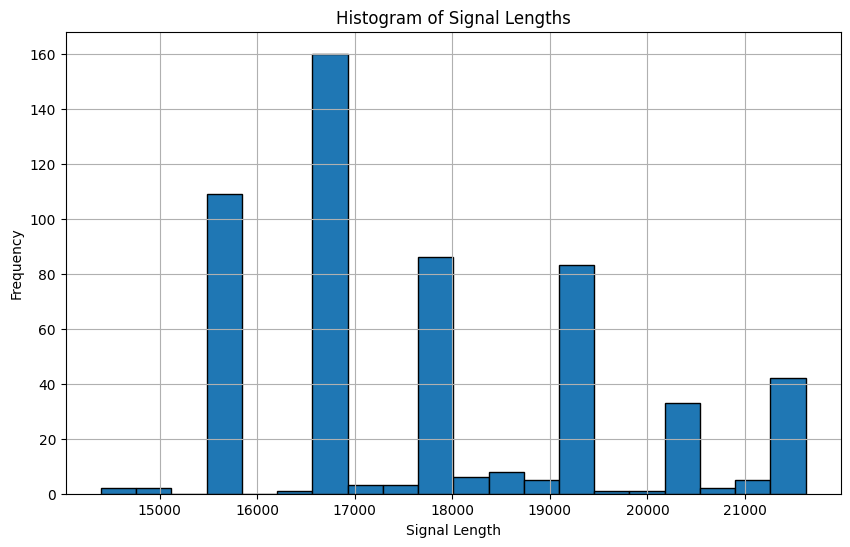

In [30]:
# plot sig_lens as histogram

import matplotlib.pyplot as plt

# Assuming sig_lens is a dictionary where keys are record IDs and values are signal lengths
# Create a list of signal lengths
sig_lens_values = list(sig_lens.values())

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(sig_lens_values, bins=20, edgecolor='black')  # Adjust bins as needed
plt.xlabel('Signal Length')
plt.ylabel('Frequency')
plt.title('Histogram of Signal Lengths')
plt.grid(True)
plt.show()


In [31]:
record_1001.record_name

'1001'

In [32]:
record_1001.comments

['----- Additional parameters for record 1001',
 '-- Outcome measures',
 'pH           7.14',
 'BDecf        8.14',
 'pCO2         7.7',
 'BE           -10.5',
 'Apgar1       6',
 'Apgar5       8',
 '-- !NotReadyYet! Neonatology outcome measures !NotReadyYet!',
 'NICU days    0',
 'Seizures     0',
 'HIE          0',
 'Intubation   0',
 'Main diag.   0',
 'Other diag.  0',
 '-- Fetus/Neonate descriptors',
 'Gest. weeks  37',
 'Weight(g)    2660',
 'Sex          2',
 '-- Maternal (risk-)factors',
 'Age          32',
 'Gravidity    1',
 'Parity       0',
 'Diabetes     1',
 'Hypertension 0',
 'Preeclampsia 0',
 'Liq. praecox 1',
 'Pyrexia      0',
 'Meconium     0',
 '-- Delivery descriptors',
 'Presentation 2',
 'Induced      0',
 'I.stage      232',
 'NoProgress   0',
 'CK/KP        0',
 'II.stage     20',
 'Deliv. type  1',
 '-- Signal information',
 'dbID         974204',
 'Rec. type    1',
 'Pos. II.st.  14400',
 'Sig2Birth    0']

In [50]:
# Desired keys to extract
desired_keys = {
    'pH', 'BDecf', 'pCO2', 'BE', 'Apgar1', 'Apgar5',
    'Gest. weeks', 'Weight(g)', 'Sex', 'Age',
    'Gravidity', 'Parity', 'Diabetes', 'Hypertension',
    'Preeclampsia', 'Liq. praecox', 'Pyrexia', 'Meconium',
    'Presentation', 'Induced', 'I.stage', 'NoProgress',
    'CK/KP', 'II.stage', 'Deliv. type', 'dbID',
    'Rec. type', 'Pos. II.st.', 'Sig2Birth'
}

def extract_comments(record):

    parsed_dict = {}

    for entry in record.comments:
        parts = entry.split(maxsplit=1)  # Split into key and value
        if len(parts) == 2:
            key, value = parts
            # if key in desired_keys:
            try:
                parsed_dict[key] = float(value)# if '.' in value else int(value)
            except ValueError:
                parsed_dict[key] = value  # Keep as string if conversion fails
        if entry.startswith("Deliv"):  # Explicitly handle "Deliv. type"
            key, value = "Deliv. type", entry.split()[-1]  # Extract value correctly
            parsed_dict[key] = int(value)  # Convert to integer
    return parsed_dict


parsed_dict = extract_comments(record_1001)

# Print the final dictionary
print(parsed_dict)

{'-----': 'Additional parameters for record 1001', '--': 'Signal information', 'pH': 7.14, 'BDecf': 8.14, 'pCO2': 7.7, 'BE': -10.5, 'Apgar1': 6.0, 'Apgar5': 8.0, 'NICU': 'days    0', 'Seizures': 0.0, 'HIE': 0.0, 'Intubation': 0.0, 'Main': 'diag.   0', 'Other': 'diag.  0', 'Gest.': 'weeks  37', 'Weight(g)': 2660.0, 'Sex': 2.0, 'Age': 32.0, 'Gravidity': 1.0, 'Parity': 0.0, 'Diabetes': 1.0, 'Hypertension': 0.0, 'Preeclampsia': 0.0, 'Liq.': 'praecox 1', 'Pyrexia': 0.0, 'Meconium': 0.0, 'Presentation': 2.0, 'Induced': 0.0, 'I.stage': 232.0, 'NoProgress': 0.0, 'CK/KP': 0.0, 'II.stage': 20.0, 'Deliv.': 'type  1', 'Deliv. type': 1, 'dbID': 974204.0, 'Rec.': 'type    1', 'Pos.': 'II.st.  14400', 'Sig2Birth': 0.0}


In [55]:
pH_list = [extract_comments(record)['pH'] for record in all_records.values()]

Weight = [extract_comments(record)['Weight(g)'] for record in all_records.values()]
Weight = [w for w in Weight if w != 'NaN']
Weight = [float(w)/1000 for w in Weight]

Age = [extract_comments(record)['Age'] for record in all_records.values()]
presentation = [extract_comments(record)['Presentation'] for record in all_records.values()]
induced = [extract_comments(record)['Induced'] for record in all_records.values()]
delivery = [extract_comments(record)['Deliv. type'] for record in all_records.values()]


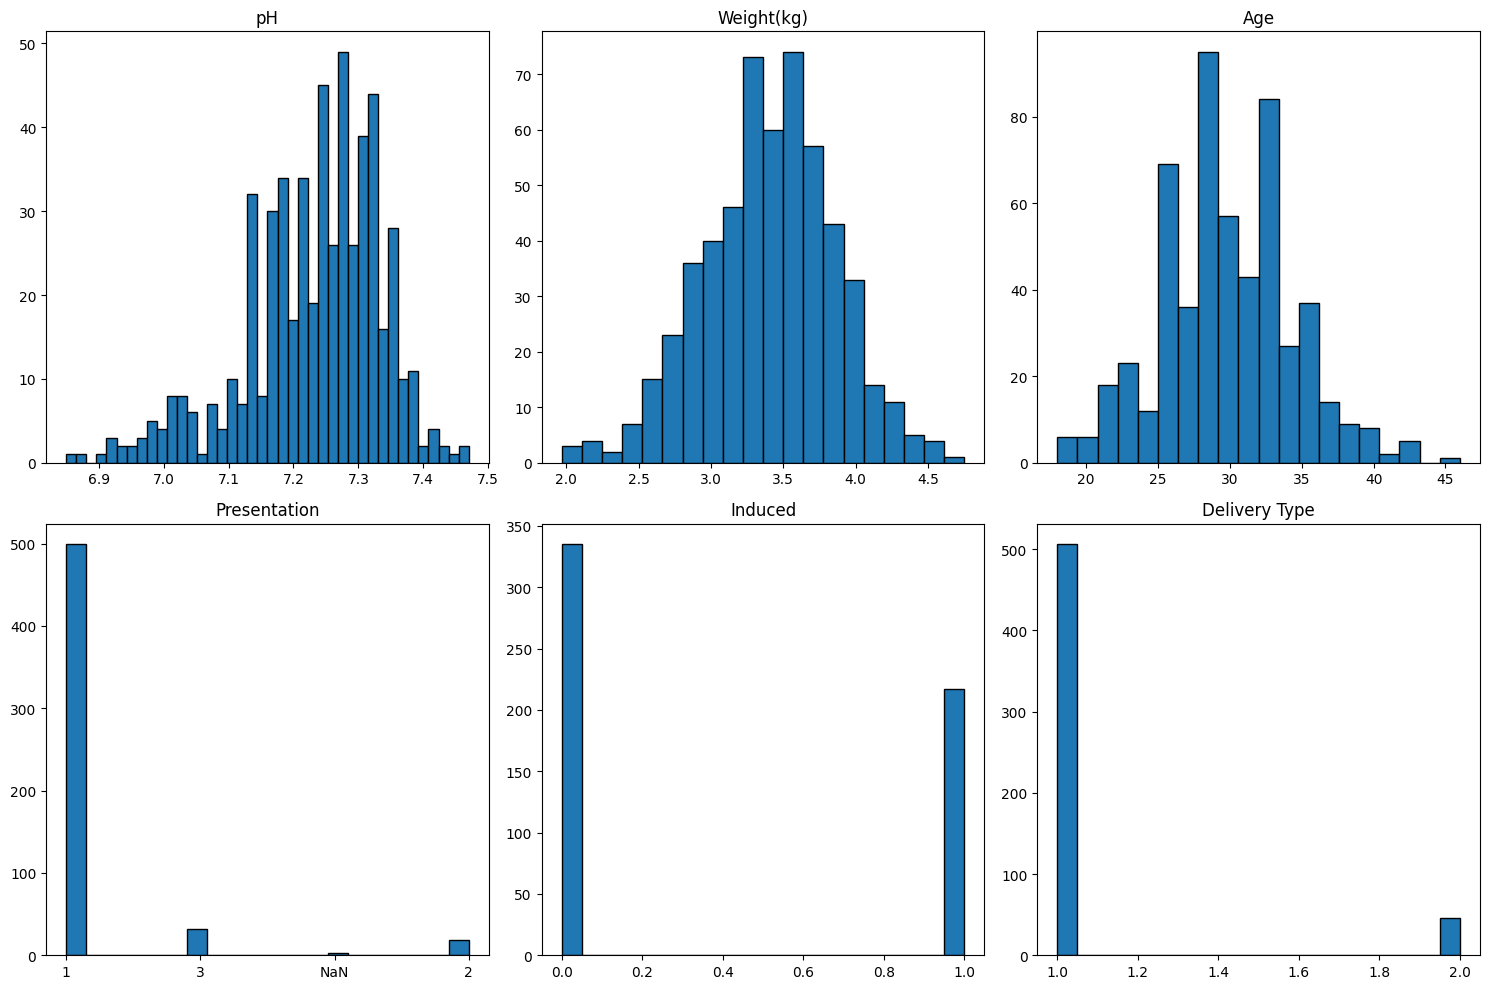

In [35]:
# prompt: make 2 rows of 3 subplots in each row of hisplots of those lists

import matplotlib.pyplot as plt

# Assuming pH_list, Weight, Age, presentation, induced, and delivery are defined

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(pH_list, bins=40, edgecolor='black')
axes[0, 0].set_title('pH')

axes[0, 1].hist(Weight, bins=20, edgecolor='black')
axes[0, 1].set_title('Weight(kg)')

axes[0, 2].hist(Age, bins=20, edgecolor='black')
axes[0, 2].set_title('Age')

axes[1, 0].hist(presentation, bins=20, edgecolor='black')
axes[1, 0].set_title('Presentation')

axes[1, 1].hist(induced, bins=20, edgecolor='black')
axes[1, 1].set_title('Induced')

axes[1, 2].hist(delivery, bins=20, edgecolor='black')
axes[1, 2].set_title('Delivery Type')


plt.tight_layout()
plt.show()


In [36]:
import numpy as np
import scipy.interpolate as interp
import copy

import numpy as np
import scipy.interpolate as interp

def preprocess_fhr(fhr, fs=4, interpolation = "cubic"):
    """
    Preprocess fetal heart rate (FHR) data:
    1. Replace extreme values (>210 or <50) and NaNs with 0.
    2. Use cubic spline interpolation for missing (zero) values.

    Parameters:
        fhr (numpy array): The fetal heart rate time series.
        max_missing_duration (int): Maximum duration for interpolation in seconds.

    Returns:
        numpy array: The preprocessed FHR data.
    """
    max_missing_duration=10*60*fs

    # deep copy fhr
    fhr = copy.deepcopy(fhr)

    time = np.arange(len(fhr))

    # Identify missing values (NaNs)
    missing_mask = np.isnan(fhr)

    # Identify extreme values (above 210 or below 50)
    extreme_mask = (fhr > 210) | (fhr < 50)

    # Replace extreme values and NaNs with 0
    fhr[missing_mask | extreme_mask] = 0

    # Identify all zero values for interpolation
    zero_mask = fhr == 0

    # Find valid (nonzero) values
    valid_idx = np.where(fhr != 0)[0]

    if interpolation == "cubic":
        if len(valid_idx) > 3:  # Need at least 4 points for cubic interpolation
            interpolator = interp.CubicSpline(valid_idx, fhr[valid_idx])
            fhr[zero_mask] = interpolator(np.where(zero_mask)[0])
    else:
        if len(valid_idx) > 1:  # Ensure there are at least two points for interpolation
            interpolator = interp.interp1d(valid_idx, fhr[valid_idx], kind='linear', bounds_error=False, fill_value="extrapolate")
            fhr[zero_mask] = interpolator(np.where(zero_mask)[0])

    return fhr


processed_fhr = copy.deepcopy(record_1001.p_signal[:, 0])

processed_record_1001 = copy.deepcopy(record_1001)

linear = preprocess_fhr(processed_fhr)
cubic = preprocess_fhr(processed_fhr, interpolation="linear")

# compare linear and cubic element wise:
indices_of_diff = []
liner_values_in_diff = []
cubic_values_in_diff = []
for i in range(len(linear)):
  if linear[i] != cubic[i]:
    indices_of_diff.append(i)
    liner_values_in_diff.append(linear[i])
    cubic_values_in_diff.append(cubic[i])

import pandas as pd

plot_indices = indices_of_diff
plt.plot(indices_of_diff, liner_values_in_diff, "x")
plt.plot(indices_of_diff, cubic_values_in_diff, "o")
plt.legend(["linear", "cubic"])
plt.show()
# plot(pd.Series(cubic[plot_indices]))

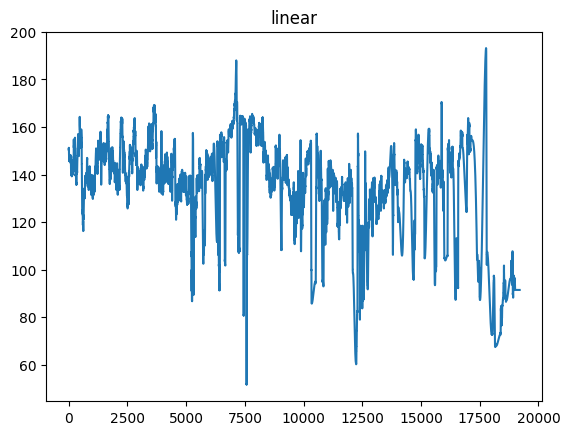

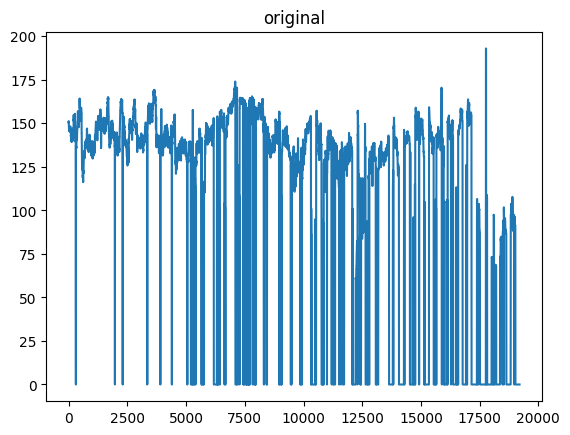

In [37]:
plt.plot(linear)
plt.title("linear")
plt.show()
plt.plot(cubic)
plt.title("cubic")
plt.show()
plt.plot(record_1001.p_signal[:, 0])
plt.title("original")
plt.show()

In [38]:
# prompt: create a pytorch tensor, in which first dimension is different records (indexed by record name), second dimension is: , fhr, uc, third dimension its the values of the fhr and uc
# so we have n(records)*2*maximum_len(fhr)

import torch

def create_pytorch_tensor(records,process = False):
    """
    Creates a PyTorch tensor from a dictionary of wfdb records.

    Args:
        records: A dictionary where keys are record names and values are wfdb.Record objects.

    Returns:
        A PyTorch tensor of shape (num_records, 2, max_signal_length)
        or None if input is invalid.
    """
    if not isinstance(records, dict):
        print("Error: Input must be a dictionary of wfdb records.")
        return None

    # Find maximum signal length for padding
    max_signal_length = 0
    for record in records.values():
      max_signal_length = max(max_signal_length, len(record.p_signal))

    num_records = len(records)
    tensor_data = []

    for record_name, record in records.items():
        # Pad signals to max length
        fhr = record.p_signal[:,0]
        if process:
          fhr = preprocess_fhr(fhr)
        uc = record.p_signal[:,1]
        fhr_padded = np.pad(fhr, (0, max_signal_length-len(fhr)), 'constant') # padding at the end, switch 0 and max_signal_length-len(fhr)
        uc_padded = np.pad(uc, (0, max_signal_length-len(uc)), 'constant')

        # Stack and append to list
        record_tensor = np.stack([fhr_padded, uc_padded], axis=0)
        tensor_data.append(record_tensor)

    # Convert the list of numpy arrays to a single numpy array
    tensor_data = np.array(tensor_data)
    # Convert to PyTorch tensor
    tensor = torch.tensor(tensor_data, dtype=torch.float32)
    return tensor

# Example usage assuming 'all_records' is your dictionary of wfdb records
# Replace this example with your actual records dictionary
#Example usage: Assuming all_records dictionary is available.
pytorch_tensor = create_pytorch_tensor(all_records)
pytorch_tensor_processed = create_pytorch_tensor(all_records, process = True)

if pytorch_tensor is not None:
  print(pytorch_tensor.shape)
    # Now you can use the pytorch_tensor for further processing.


torch.Size([552, 2, 21620])


In [39]:
record_metadata = {}
for record in all_records.values():
    record_metadata[record.record_name] = extract_comments(record)

In [40]:
# Important variables:

all_records; # Dictionary, {record_name: Record}
pytorch_tensor; # Pytorch tensor, [552, 2, 21620], records*(fhr,uc)*values, values padded at the end
pytorch_tensor_processed; # pPytorch tensor, [552, 2, 21620], fhr is proccessed - interpolated missing and extreme (<50 or >210) datapoints.
record_metadata; # Dictionary, {record_name: metadata}

In [41]:
records_file = '/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/data/ctu_chb_data/RECORDS'
records = []

import csv 


with open(records_file, "r") as file:
    reader = csv.reader(file)
    for row in reader:
        if row:  # Ensure the row is not empty
            records.append((row[0])) 

In [42]:
records

['1001',
 '1002',
 '1003',
 '1004',
 '1005',
 '1006',
 '1007',
 '1008',
 '1009',
 '1010',
 '1011',
 '1012',
 '1013',
 '1014',
 '1015',
 '1016',
 '1017',
 '1018',
 '1019',
 '1020',
 '1021',
 '1022',
 '1023',
 '1024',
 '1025',
 '1026',
 '1027',
 '1028',
 '1029',
 '1030',
 '1031',
 '1032',
 '1033',
 '1034',
 '1035',
 '1036',
 '1037',
 '1038',
 '1039',
 '1040',
 '1041',
 '1042',
 '1043',
 '1044',
 '1045',
 '1046',
 '1047',
 '1048',
 '1049',
 '1050',
 '1051',
 '1052',
 '1053',
 '1054',
 '1055',
 '1056',
 '1057',
 '1058',
 '1059',
 '1060',
 '1061',
 '1062',
 '1063',
 '1064',
 '1065',
 '1066',
 '1067',
 '1068',
 '1069',
 '1070',
 '1071',
 '1072',
 '1073',
 '1074',
 '1075',
 '1076',
 '1077',
 '1078',
 '1079',
 '1080',
 '1081',
 '1082',
 '1083',
 '1084',
 '1085',
 '1086',
 '1087',
 '1088',
 '1089',
 '1090',
 '1091',
 '1092',
 '1093',
 '1094',
 '1095',
 '1096',
 '1097',
 '1098',
 '1099',
 '1100',
 '1101',
 '1102',
 '1103',
 '1104',
 '1105',
 '1106',
 '1107',
 '1108',
 '1109',
 '1110',
 '1111',
 

In [54]:
X_gestational = []

all_records = read_records(data_dir)

for record in records:
    record = all_records[record]
    record_dict = extract_comments(record)
    # print(record_dict)
    # print(record.comments)
    X_gestational.append(int(record_dict['Gest.'].split()[1]))


X_gestational


[37,
 41,
 40,
 41,
 41,
 38,
 41,
 39,
 39,
 38,
 38,
 41,
 40,
 42,
 41,
 40,
 41,
 39,
 41,
 41,
 37,
 39,
 41,
 40,
 41,
 37,
 41,
 42,
 41,
 40,
 37,
 43,
 40,
 41,
 38,
 40,
 41,
 39,
 40,
 41,
 41,
 41,
 41,
 38,
 40,
 40,
 40,
 39,
 39,
 41,
 40,
 40,
 40,
 37,
 40,
 42,
 41,
 39,
 40,
 39,
 39,
 40,
 41,
 41,
 40,
 41,
 40,
 41,
 38,
 41,
 39,
 41,
 40,
 40,
 41,
 38,
 39,
 39,
 41,
 40,
 37,
 40,
 40,
 40,
 39,
 42,
 37,
 38,
 41,
 39,
 39,
 41,
 40,
 38,
 41,
 39,
 41,
 41,
 40,
 41,
 40,
 39,
 39,
 40,
 41,
 41,
 40,
 40,
 39,
 41,
 38,
 40,
 40,
 39,
 40,
 41,
 40,
 41,
 41,
 41,
 41,
 40,
 40,
 38,
 40,
 40,
 39,
 38,
 38,
 39,
 39,
 40,
 39,
 40,
 39,
 40,
 41,
 40,
 41,
 40,
 40,
 41,
 41,
 40,
 41,
 41,
 39,
 41,
 41,
 40,
 41,
 40,
 40,
 39,
 38,
 41,
 41,
 40,
 41,
 41,
 41,
 39,
 41,
 40,
 38,
 40,
 40,
 37,
 40,
 39,
 40,
 41,
 39,
 39,
 40,
 39,
 41,
 42,
 40,
 39,
 38,
 40,
 42,
 41,
 41,
 40,
 40,
 41,
 39,
 41,
 40,
 40,
 40,
 40,
 41,
 41,
 39,
 39,
 40,
 39,


### LSTM with Weight

In [ ]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
from scripts.load_data import prepare_data

In [56]:
import torch

# Define the path to your tensor file
tensor_path = "/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/data/processed/ctg_tensor.pt"

# Load the tensor
ctg_tensor = torch.load(tensor_path)

# Check the shape of the tensor
print(ctg_tensor.shape)  # Verify dimensions (batch_size, seq_length, features)


torch.Size([552, 21620, 2])


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model

# Define input shapes
time_input = Input(shape=(None, num_time_features), name="time_series_input")  # Time-series input
bmi_input = Input(shape=(1,), name="bmi_input")  # Scalar BMI input

# LSTM branch
x = LSTM(64, return_sequences=True)(time_input)
x = LSTM(32)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.3)(x)

# BMI branch
b = Dense(16, activation="relu")(bmi_input)
b = Dense(8, activation="relu")(b)

# Concatenate the two feature branches
merged = Concatenate()([x, b])
merged = Dense(32, activation="relu")(merged)
merged = Dropout(0.3)(merged)
output = Dense(1, activation="sigmoid", name="output")(merged)

# Define model
model = Model(inputs=[time_input, bmi_input], outputs=output)

# Compile model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Model summary
model.summary()

In [57]:
import scripts.LSTM_fusion as LSTMF

# Define model parameters
input_dim = ctg_tensor.shape[2]  # Number of features per time step
hidden_dim = 128
num_layers = 2
weight_dim = 1  # Scalar input for weight

# Initialize model
model = LSTMF.LSTMFusionModel(input_dim, hidden_dim, num_layers, weight_dim)

# Sample inputs
time_series_sample = torch.randn(32, ctg_tensor.shape[1], input_dim)  # (batch_size, seq_length, features)
weight_sample = torch.randn(32, 1)  # (batch_size, 1)

# Forward pass
output = model(time_series_sample, weight_sample)
print(output.shape)  # Expected: (32, 1)


torch.Size([32, 1])


In [58]:
import torch

# Load time series data
tensor_path = "/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/data/processed/ctg_tensor.pt"
ctg_tensor = torch.load(tensor_path)

# Check shape
print("CTG Tensor shape:", ctg_tensor.shape)  # Expected: (num_samples, seq_length, num_features)


CTG Tensor shape: torch.Size([552, 21620, 2])


In [61]:
import torch
from sklearn.preprocessing import MinMaxScaler

# Convert list to PyTorch tensor
weight_tensor = torch.tensor(Weight, dtype=torch.float32).unsqueeze(1)  # Reshape to (num_samples, 1)

# Normalize using Min-Max Scaling
scaler = MinMaxScaler()
weight_tensor = torch.tensor(scaler.fit_transform(weight_tensor), dtype=torch.float32)

# Check shape
print("Weight Tensor shape:", weight_tensor.shape)  # Expected: (num_samples, 1)


Weight Tensor shape: torch.Size([552, 1])


In [62]:
assert len(ctg_tensor) == len(weight_tensor), "Mismatch: ctg_tensor and weight_tensor lengths do not match!"


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
import scripts.load_data

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function & optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy for classification
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for time_series, weight, labels in train_loader:
        time_series, weight, labels = time_series.to(device), weight.to(device), labels.to(device)

        # Forward pass
        outputs = model(time_series, weight)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += l


NameError: name 'train_loader' is not defined

In [ ]:
ROOT_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
os.chdir(ROOT_DIR)

# Set other directories
MODEL_DIR = os.path.join(ROOT_DIR, 'models')
DATA_DIR = os.path.join(ROOT_DIR, 'data')

# Data paths
data_path = os.path.join(DATA_DIR, "processed", "ctg_tensor.pt")
labels_path = os.path.join(DATA_DIR, "processed", "labels.csv")

print(f"Root Directory: {ROOT_DIR}")
print(f"Model Directory: {MODEL_DIR}")
print(f"Data Directory: {DATA_DIR}")
print(f"Data Path: {data_path}")
print(f"Labels Path: {labels_path}")

# Hyperparameters
input_size = 2 # Batch data shape: torch.Size([32, 2, 21620]), Batch labels shape: torch.Size([32])
hidden_size = 64
num_layers = 2
num_classes = 2  # Assuming binary classification, adjust if needed
learning_rate = 0.001
num_epochs = 10
batch_size = 32

# Prepare data
train_loader, val_loader = prepare_data(data_path, labels_path, batch_size) #, include_test=True)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = LSTMClassifier(input_size, hidden_size, num_layers, num_classes).to(device)

# Loss and optimizer
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
# train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)

# Plot losses
# plot_losses(train_losses, val_losses)

# # Save the model
# torch.save(model.state_dict(), f'{MODEL_DIR}/lstm_model.pth')
print("LSTM model saved successfully.")


############## LSTM WITH CLASS WEIGHTS ###################################################################
# Assuming y is a numpy array with binary labels (0 or 1)
labels = pd.read_csv(labels_path)['label'].to_list()
classes = np.unique(labels)
class_weights = compute_class_weight("balanced", classes=classes, y=labels)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}

# Convert to tensor
class_weights_tensor = torch.tensor([class_weights_dict[0], class_weights_dict[1]], dtype=torch.float32)

# Define weighted BCE loss
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights_tensor[1])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CTGLSTM(input_size=input_size).to(device)
print(model.parameters())
print("model built")
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# Train the model
print("starting training")
train_losses, val_losses = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device)

# Plot losses
plot_losses(train_losses, val_losses)

# Save the model
torch.save(model.state_dict(), f'{MODEL_DIR}/CTGlstm_model.pth')
print("LSTM + Weights Model saved successfully.")



### Perplexity Code

In [65]:
import torch
import torch.nn as nn

class CTGWeightClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # LSTM for CTG data (2 features)
        self.lstm = nn.LSTM(input_size=2, 
                          hidden_size=64,
                          num_layers=2,
                          batch_first=True,
                          bidirectional=True)
        
        # Weight embedding
        self.weight_proj = nn.Linear(1, 32)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(64*2 + 32, 128),  # 64*2 for bidirectional
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, ctg, weight):
        # CTG processing
        lstm_out, _ = self.lstm(ctg)  # [batch, seq_len, hidden*2]
        lstm_features = lstm_out[:, -1, :]  # Last timestep
        
        # Weight processing
        weight = weight.unsqueeze(-1)  # [batch, 1]
        weight_features = self.weight_proj(weight)
        
        # Feature fusion
        combined = torch.cat([lstm_features, weight_features], dim=1)
        
        return self.classifier(combined)


In [66]:
from torch.utils.data import Dataset, DataLoader

class CTGDataset(Dataset):
    def __init__(self, ctg_tensor, weights, labels):
        self.ctg = ctg_tensor  # Shape [552, 21620, 2]
        self.weights = torch.FloatTensor(weights)
        self.labels = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.ctg)

    def __getitem__(self, idx):
        return {
            'ctg': self.ctg[idx],
            'weight': self.weights[idx],
            'label': self.labels[idx]
        }


In [ ]:
# For weights
self.weights = (self.weights - mean_weight) / std_weight

# For CTG signals
self.ctg = (self.ctg - ctg_mean) / ctg_std

TypeError: pack_padded_sequence() missing 2 required positional arguments: 'input' and 'lengths'

In [69]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

# Configuration
class Config:
    seed = 42
    test_size = 0.2
    batch_size = 16
    num_epochs = 30
    learning_rate = 1e-3
    weight_decay = 1e-4
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset Class
class CTGDataset(Dataset):
    def __init__(self, ctg_tensor, weights, labels):
        self.ctg = ctg_tensor.float()
        self.weights = torch.FloatTensor(weights)
        self.labels = torch.FloatTensor(labels)
        
        # Normalize
        self.weight_mean, self.weight_std = self.weights.mean(), self.weights.std()
        self.ctg_mean, self.ctg_std = self.ctg.mean((0,1)), self.ctg.std((0,1))
        
        self.weights = (self.weights - self.weight_mean) / self.weight_std
        self.ctg = (self.ctg - self.ctg_mean) / self.ctg_std

    def __len__(self):
        return len(self.ctg)

    def __getitem__(self, idx):
        return {
            'ctg': self.ctg[idx],
            'weight': self.weights[idx],
            'label': self.labels[idx]
        }

# Model Architecture
class CTGWeightClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2, 64, num_layers=2, 
                           bidirectional=True, batch_first=True)
        self.weight_proj = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64*2 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, ctg, weight):
        lstm_out, _ = self.lstm(ctg)
        temporal_features = lstm_out[:, -1]
        weight_features = self.weight_proj(weight.unsqueeze(-1))
        combined = torch.cat([temporal_features, weight_features], dim=1)
        return self.classifier(combined)

# Training Function
def train_model(model, train_loader, val_loader, config):
    model.to(config.device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), 
                                lr=config.learning_rate,
                                weight_decay=config.weight_decay)
    
    best_auc = 0
    history = {'train_loss': [], 'val_auc': [], 'val_acc': []}

    for epoch in range(config.num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in train_loader:
            ctg = batch['ctg'].to(config.device)
            weight = batch['weight'].to(config.device)
            labels = batch['label'].to(config.device)
            
            optimizer.zero_grad()
            outputs = model(ctg, weight).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation
        val_auc, val_acc = evaluate(model, val_loader, config)
        train_loss = epoch_loss/len(train_loader)
        
        history['train_loss'].append(train_loss)
        history['val_auc'].append(val_auc)
        history['val_acc'].append(val_acc)
        
        # Save best model
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), 'best_model.pth')
        
        print(f"Epoch {epoch+1}/{config.num_epochs}")
        print(f"Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f} | Val Acc: {val_acc:.4f}")
    
    return history

# Evaluation Function
def evaluate(model, loader, config):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            ctg = batch['ctg'].to(config.device)
            weight = batch['weight'].to(config.device)
            labels = batch['label'].cpu().numpy()
            
            outputs = model(ctg, weight).squeeze().cpu().numpy()
            preds = 1/(1 + np.exp(-outputs))  # Sigmoid
            
            all_preds.extend(preds)
            all_labels.extend(labels)
    
    auc = roc_auc_score(all_labels, all_preds)
    acc = accuracy_score(all_labels, np.round(all_preds))
    return auc, acc



# Key enhancements from initial version:
# - Full data pipeline with normalization
# - Complete training loop with validation
# - Model checkpointing
# - Progress tracking and visualization
# - Proper device management
# - Regularization with weight decay and dropout
# - Evaluation metrics (AUC + Accuracy)


In [76]:
ctg_tensor = torch.load(tensor_path)

# Count NaN values
nan_count = torch.isnan(ctg_tensor).sum().item()

if nan_count > 0:
    print(f"Found {nan_count} NaN values in CTG tensor, replacing with 0")
    ctg_tensor = torch.nan_to_num(ctg_tensor, nan=0.0)
else:
    print("No NaN values found in CTG tensor")

# Optional: Print tensor shape and total elements for context
print(f"Tensor shape: {ctg_tensor.shape}")
print(f"Total elements: {ctg_tensor.numel()}")
print(f"Percentage of NaN values: {nan_count / ctg_tensor.numel() * 100:.4f}%")


No NaN values found in CTG tensor
Tensor shape: torch.Size([552, 21620, 2])
Total elements: 23868480
Percentage of NaN values: 0.0000%


In [77]:
from scipy import stats
# Load data
ROOT_DIR = "/Users/devleibowitz/Documents/TAU Courses/Deep Learning Raja/HW/dl_homeworks/Multimodal_Fusion_TimeSeries_Models/"
os.chdir(ROOT_DIR)

# Set other directories
MODEL_DIR = os.path.join(ROOT_DIR, 'models')
DATA_DIR = os.path.join(ROOT_DIR, 'data')

# Data paths
data_path = os.path.join(DATA_DIR, "processed", "ctg_tensor.pt")
labels_path = os.path.join(DATA_DIR, "processed", "labels.csv")

ctg_tensor = torch.load(tensor_path)
# Handle NaN in CTG data
if torch.isnan(ctg_tensor).any():
    print("NaN values in CTG tensor, replacing with 0")
    ctg_tensor = torch.nan_to_num(ctg_tensor, nan=0.0)


labels = pd.read_csv(labels_path)['label'].to_list()

# Load weights with mode replacement
weights = np.array(Weight)

if np.isnan(weights).any():
    # Calculate mode of non-NaN values
    mode_result = stats.mode(weights[~np.isnan(weights)], keepdims=False)
    mode_weight = mode_result.mode
    print(f"Replaced {np.isnan(weights).sum()} NaN values with mode: {mode_weight}")
    weights = np.nan_to_num(weights, nan=mode_weight)


# Create dataset
full_dataset = CTGDataset(ctg_tensor, weights, labels)

# Split dataset
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.batch_size)

# Initialize model
model = CTGWeightClassifier()

# Train
history = train_model(model, train_loader, val_loader, Config)

# Plot results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(history['val_auc'], label='Validation AUC')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Validation Metrics')
plt.legend()
plt.show()


Replaced 1 NaN values with mode: 3.5
Epoch 1/30
Train Loss: 0.6638 | Val AUC: 0.4156 | Val Acc: 0.6486
Epoch 2/30
Train Loss: 0.6591 | Val AUC: 0.4056 | Val Acc: 0.6486
Epoch 3/30
Train Loss: 0.6588 | Val AUC: 0.4049 | Val Acc: 0.6486
Epoch 4/30
Train Loss: 0.6591 | Val AUC: 0.3889 | Val Acc: 0.6486


KeyboardInterrupt: 